# Benchmark

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
sizes = [16, 64, 128, 256, 512, 1024]

filenames = [f"serial_benchmark/benchmark_H{size}_L1.csv" for size in sizes]
apple_frames = []
for filename in filenames:
    apple_frames.append(pd.read_csv(filename))



filenames = [f"serial_benchmark/JETSON_benchmark_H{size}_L1.csv" for size in sizes]
jetson_frames = []
for filename in filenames:
    jetson_frames.append(pd.read_csv(filename))

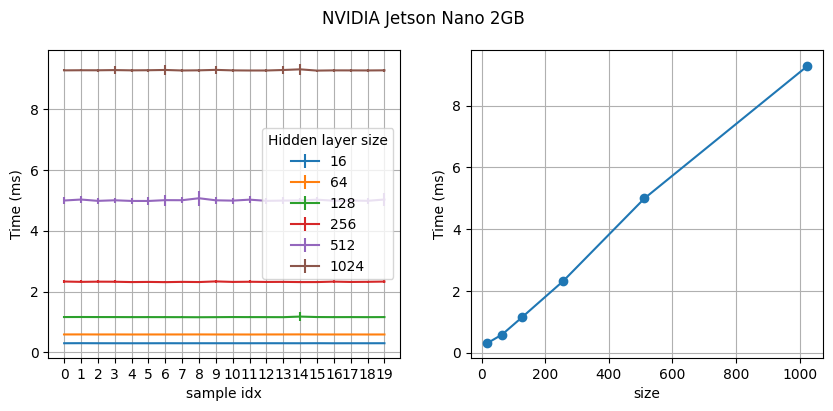

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

ax = axs[0]
for i, size in enumerate(sizes):
    df = jetson_frames[i]
    mean = df.mean(axis = 1)
    std = df.std(axis = 1)
    ax.errorbar(x = np.arange(0, len(mean)), y= mean, yerr = std, label = f"{size}")

ax.legend(title = "Hidden layer size")
ax.set_xticks(np.arange(0, len(mean) ))
ax.set_xlabel("sample idx")
ax.set_ylabel("Time (ms)")
ax.grid()

ax = axs[1]
mean_time = []
std_time = []
for i, size in enumerate(frames):
    df = frames[i].iloc[:, 1:]
    mean_time.append(df.to_numpy().mean())
    std_time.append(df.to_numpy().std())

ax.errorbar(x = sizes, y= mean_time, yerr = std_time, marker = "o")
ax.set_xlabel("size")
ax.set_ylabel("Time (ms)")
ax.grid()
plt.suptitle("NVIDIA Jetson Nano 2GB")
plt.savefig("serial_benchmark/jetson_serial.pdf")

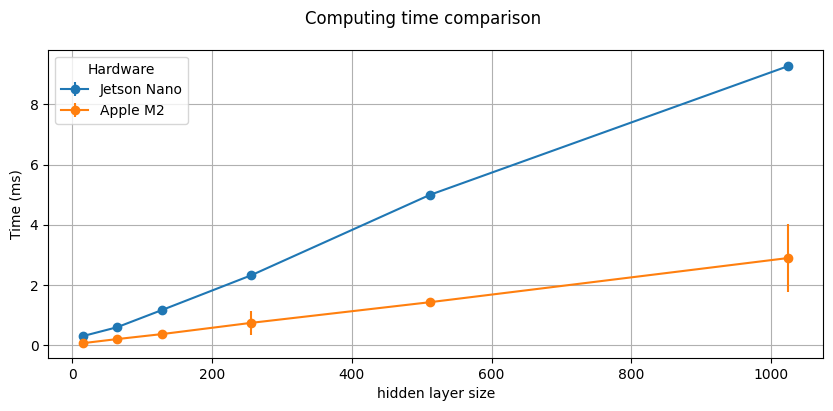

In [17]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10, 4))


jetson_mean_time = []
jetson_std_time = []

apple_mean_time = []
apple_std_time = []

for i, size in enumerate(sizes):
    df = jetson_frames[i].iloc[:, 1:]
    jetson_mean_time.append(df.to_numpy().mean())
    jetson_std_time.append(df.to_numpy().std())


    df = apple_frames[i].iloc[:, 1:]
    apple_mean_time.append(df.to_numpy().mean())
    apple_std_time.append(df.to_numpy().std())


ax.errorbar(x = sizes, y= jetson_mean_time, yerr = jetson_std_time, marker = "o", label = "Jetson Nano")
ax.errorbar(x = sizes, y= apple_mean_time, yerr = apple_std_time, marker = "o", label = "Apple M2")
ax.set_xlabel("hidden layer size")
ax.set_ylabel("Time (ms)")
ax.grid()
ax.legend(title = "Hardware")

plt.suptitle("Computing time comparison")
plt.savefig("serial_benchmark/comparison_serial.pdf")